In [2]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# 1 · Load Point Cloud

In [5]:

data_path = r'../Data/indoor_scene.xyz'
pcd = o3d.io.read_point_cloud(data_path, format='xyz')
pcd_center = pcd.get_center()
pcd.translate(-pcd_center)
print(pcd)
o3d.visualization.draw_geometries([pcd])

PointCloud with 22100 points.


# 2 · Voxel Downsampling

In [6]:
voxel_size = 0.05
pcd_down = pcd.voxel_down_sample(voxel_size)
print(f'Downsampled: {len(pcd_down.points)} points')
o3d.visualization.draw_geometries([pcd_down])

Downsampled: 19820 points


# 3 · Feature Extraction
Build a feature matrix: XYZ + normalised height + local density

In [7]:
pts = np.asarray(pcd_down.points)

# Compute local density via nearest-neighbour distance
nn_dists = np.array(pcd_down.compute_nearest_neighbor_distance())

# Feature matrix: x, y, z, height-above-floor, local_density
z_norm = (pts[:, 2] - pts[:, 2].min()) / (pts[:, 2].max() - pts[:, 2].min())
features = np.column_stack([pts, z_norm, nn_dists])

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(f'Feature matrix: {features_scaled.shape}')
print('Features: x, y, z, z_normalised, nn_distance')

Feature matrix: (19820, 5)
Features: x, y, z, z_normalised, nn_distance


# 4 · Elbow Method — Finding Optimal K

k= 2  inertia=   64487.7  silhouette=0.3824
k= 3  inertia=   54061.5  silhouette=0.2495
k= 4  inertia=   45760.1  silhouette=0.2680
k= 5  inertia=   41279.9  silhouette=0.2374
k= 6  inertia=   36969.7  silhouette=0.2416
k= 7  inertia=   35500.9  silhouette=0.2452
k= 8  inertia=   30556.2  silhouette=0.2609
k= 9  inertia=   28504.4  silhouette=0.2469
k=10  inertia=   26289.4  silhouette=0.2680
k=11  inertia=   25607.6  silhouette=0.2560


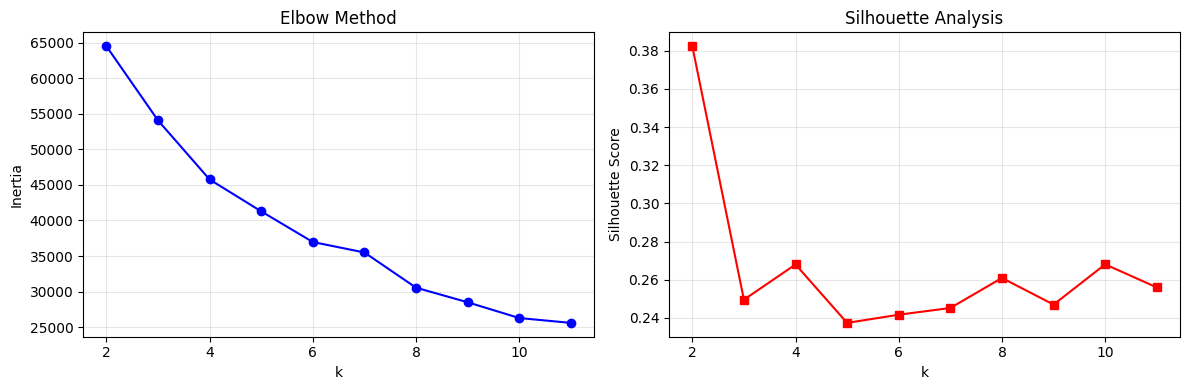

In [8]:
inertias   = []
sil_scores = []
K_range    = range(2, 12)

for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(features_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(features_scaled, labels_k, sample_size=2000))
    print(f'k={k:2d}  inertia={km.inertia_:10.1f}  silhouette={sil_scores[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_range), inertias, 'bo-')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method'); ax1.grid(alpha=0.3)
ax2.plot(list(K_range), sil_scores, 'rs-')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis'); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5 · K-Means Clustering

In [9]:
optimal_k = 8   # adjust based on elbow / silhouette plots above

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=500)
labels = kmeans.fit_predict(features_scaled)

print(f'K = {optimal_k}')
for i in range(optimal_k):
    print(f'  Cluster {i}: {(labels == i).sum():5d} points')

cmap = plt.get_cmap('tab10')
colors = cmap(labels / (optimal_k - 1))[:, :3]
pcd_down.colors = o3d.utility.Vector3dVector(colors)
o3d.visualization.draw_geometries([pcd_down])

K = 8
  Cluster 0:  2050 points
  Cluster 1:  1954 points
  Cluster 2:  3526 points
  Cluster 3:  2927 points
  Cluster 4:  1692 points
  Cluster 5:  1336 points
  Cluster 6:  1042 points
  Cluster 7:  5293 points


# 6 · Bounding Boxes + Centroids

In [10]:
geometries = [pcd_down]

for i in range(optimal_k):
    idx     = np.where(labels == i)[0]
    cluster = pcd_down.select_by_index(idx)
    bbox    = cluster.get_axis_aligned_bounding_box()
    bbox.color = cmap(i / (optimal_k - 1))[:3]
    geometries.append(bbox)
    extent = bbox.get_extent()
    cx, cy, cz = np.asarray(cluster.points).mean(axis=0)
    print(f'Cluster {i}: centroid=({cx:.2f},{cy:.2f},{cz:.2f})  '
          f'extent={extent[0]:.2f}x{extent[1]:.2f}x{extent[2]:.2f}')

o3d.visualization.draw_geometries(geometries)

Cluster 0: centroid=(-0.89,1.28,-0.80)  extent=10.11x10.14x1.57
Cluster 1: centroid=(4.29,-2.21,1.05)  extent=5.33x8.13x2.12
Cluster 2: centroid=(2.30,-2.65,-0.51)  extent=6.63x5.24x1.50
Cluster 3: centroid=(2.44,3.67,-0.61)  extent=9.14x5.46x1.70
Cluster 4: centroid=(-0.64,4.61,1.46)  extent=10.12x5.14x2.01
Cluster 5: centroid=(-3.32,-2.48,1.51)  extent=7.02x6.57x1.87
Cluster 6: centroid=(0.47,0.67,1.96)  extent=10.10x10.09x1.64
Cluster 7: centroid=(-3.22,-0.79,-0.51)  extent=5.75x10.08x1.76


# 7 · Automatic Segment Labelling

In [11]:
segment_labels = {}

for i in range(optimal_k):
    idx     = np.where(labels == i)[0]
    z_vals  = pts[idx, 2]
    z_mean  = z_vals.mean()
    z_range = z_vals.max() - z_vals.min()
    n_pts   = len(idx)

    if z_mean < -0.8 and z_range < 0.15:
        label = 'Floor'
    elif z_mean > 1.2 and z_range < 0.15:
        label = 'Ceiling'
    elif z_range > 1.5 and n_pts > 500:
        label = 'Wall'
    elif 0.3 < z_mean < 0.7 and z_range < 0.4:
        label = 'Furniture (low)'
    elif 0.7 < z_mean < 1.2:
        label = 'Furniture (mid)'
    else:
        label = f'Object {i}'

    segment_labels[i] = label
    print(f'Cluster {i} -> {label:20s}  z_mean={z_mean:.2f}  z_range={z_range:.2f}  n={n_pts}')

Cluster 0 -> Wall                  z_mean=-0.80  z_range=1.57  n=2050
Cluster 1 -> Wall                  z_mean=1.05  z_range=2.12  n=1954
Cluster 2 -> Wall                  z_mean=-0.51  z_range=1.50  n=3526
Cluster 3 -> Wall                  z_mean=-0.61  z_range=1.70  n=2927
Cluster 4 -> Wall                  z_mean=1.46  z_range=2.01  n=1692
Cluster 5 -> Wall                  z_mean=1.51  z_range=1.87  n=1336
Cluster 6 -> Wall                  z_mean=1.96  z_range=1.64  n=1042
Cluster 7 -> Wall                  z_mean=-0.51  z_range=1.76  n=5293


# 8 · 2-D Visualisation (Top + Side Views)

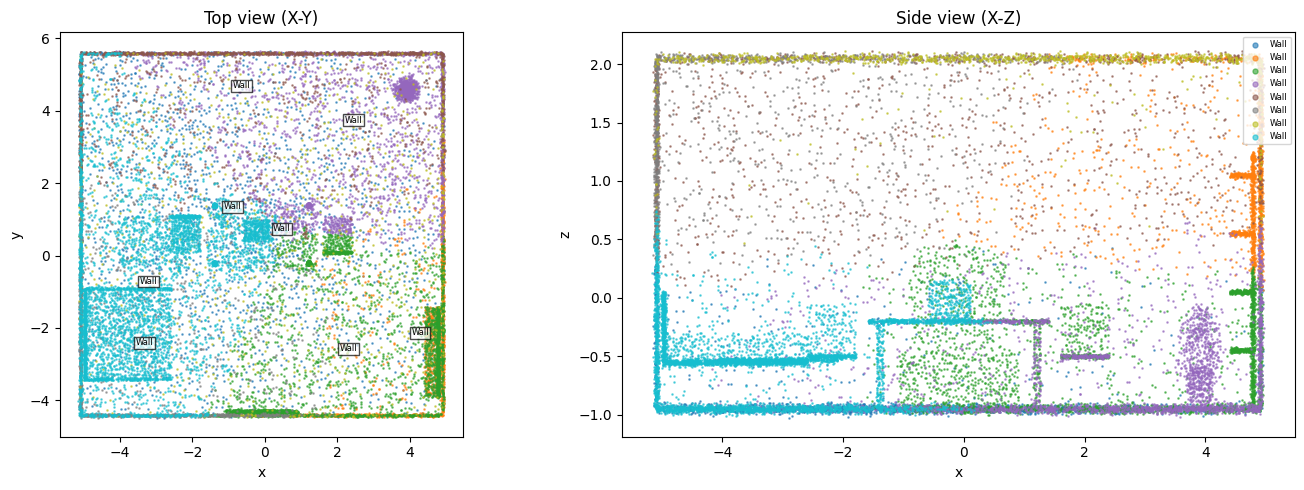

In [12]:
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121)
for i in range(optimal_k):
    idx = np.where(labels == i)[0]
    c   = cmap(i / (optimal_k - 1))
    ax1.scatter(pts[idx, 0], pts[idx, 1], c=[c], s=0.8, alpha=0.6)
    cx, cy = pts[idx, 0].mean(), pts[idx, 1].mean()
    ax1.text(cx, cy, segment_labels[i], fontsize=6, ha='center',
             bbox=dict(fc='white', alpha=0.7, pad=1))
ax1.set_title('Top view (X-Y)'); ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_aspect('equal')

ax2 = fig.add_subplot(122)
for i in range(optimal_k):
    idx = np.where(labels == i)[0]
    c   = cmap(i / (optimal_k - 1))
    ax2.scatter(pts[idx, 0], pts[idx, 2], c=[c], s=0.8, alpha=0.6,
                label=segment_labels[i])
ax2.set_title('Side view (X-Z)'); ax2.set_xlabel('x'); ax2.set_ylabel('z')
ax2.legend(fontsize=6, markerscale=4, loc='upper right')

plt.tight_layout()
plt.savefig('kmeans_result.png', dpi=150, bbox_inches='tight')
plt.show()